# Applying NLP to Gene Sequencing

### Main Objective
Classify human regulatory DNA sequences (promoters, enhancers, and open chromatin regions (OCRs)) directly from their nucleotide sequence, and compare how well three classic ML models and one recurrent neural network (LSTM) can do it.

### Background
Human DNA is built from repeating nucleotides (A, T, G, C), which can be treated as "text" for NLP-style modeling. The midterm phase of this project asked whether pairing unsupervised topic modeling with a classifier could match or beat direct supervised text classification on a small, imbalanced gene-type dataset; direct classification won clearly on every classic model tried. This final phase drops the hybrid approach, moves to a much larger and more standard benchmark dataset, and asks a different question: does a model built to respect sequence order (an LSTM) outperform classic models that only see a flat, ordered vector of k-mers?

In [ ]:
# If genomic-benchmarks isn't installed yet, run this first:
# %pip install -q genomic-benchmarks

In [ ]:
# Handle imports
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Conv1D, MaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from genomic_benchmarks.data_check import info
from genomic_benchmarks.loc2seq import download_dataset

/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/genomic_benchmarks/utils/datasets.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [24]:
RAND_STATE = 498
DATASET_NAME = "human_ensembl_regulatory"
DATASET_VERSION = 0
CLASS_NAMES = ["enhancer", "ocr", "promoter"]

VAL_SIZE = 0.125
K_MER_SIZE = 6  # standard DNA "word" length (e.g., used by DNABERT)
MAX_VOCAB_SIZE = 5000
LR_MAX_ITER = 1000
RF_N_ESTIMATORS = 100

# LSTM constants
EMBED_DIM = 64
LSTM_UNITS = 128
LSTM_DROPOUT_RATE = 0.2
LSTM_BATCH_SIZE = 256
LSTM_EPOCHS = 20
LSTM_EARLY_STOP_PATIENCE = 5
LSTM_MAX_LEN_PERCENTILE = 90
LSTM_LEARNING_RATE = 5e-4
LSTM_LR_REDUCE_FACTOR = 0.5  
LSTM_LR_REDUCE_PATIENCE = 1
LSTM_LR_MIN = 1e-6
CONV_FILTERS = 64
CONV_KERNEL_SIZE = 5

# Plots
CLASS_DIST_FIGSIZE = (8, 5)
COMPARISON_FIGSIZE = (12, 9)

# Read the Dataset
- Source: [Genomic Benchmarks](https://github.com/ML-Bioinfo-CEITEC/genomic_benchmarks) (Grešová et al., 2023), **human_ensembl_regulatory** dataset, accessed through the **genomic-benchmarks** PyPI package.

In [ ]:
# Inspect the benchmark dataset
info(DATASET_NAME, version=DATASET_VERSION)

Dataset `human_ensembl_regulatory` has 3 classes: enhancer, ocr, promoter.

The length of genomic intervals ranges from 71 to 802, with average 429.91753643694585 and median 401.0.

Totally 289061 sequences have been found, 231348 for training and 57713 for testing.


,train,test
enhancer,85512,21378
ocr,69902,17476
promoter,75934,18859


In [ ]:
# Download (or reuse the local cache of) the full-sequence version of the dataset.
dataset_path = download_dataset(DATASET_NAME, version=DATASET_VERSION)
print(f"Dataset cached at: {dataset_path}")

Dataset cached at: /Users/yao-fuyang/.genomic_benchmarks/human_ensembl_regulatory


Genomic Benchmarks stores each split as one folder per class, with every sequence saved as its own text file (**<class>/<id>.txt**). The loader below walks that structure into a single DataFrame

In [ ]:
def load_split(dataset_dir, split_name):
    """Read every sequence file in a Genomic Benchmarks split into a DataFrame."""
    rows = []
    split_dir = pathlib.Path(dataset_dir) / split_name
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        class_label = class_dir.name
        for seq_file in class_dir.iterdir():
            if seq_file.is_file():
                sequence = seq_file.read_text().strip().upper()
                rows.append((sequence, class_label))
    return pd.DataFrame(rows, columns=["NucleotideSequence", "RegulatoryClass"])

# ~289k individual files
df_train_full = load_split(dataset_path, "train")
df_test = load_split(dataset_path, "test")

print(f"Shape of full training set: {df_train_full.shape}")
print(f"Shape of test set: {df_test.shape}")
df_train_full.head()

Shape of full training set: (231348, 2)
Shape of test set: (57713, 2)


,NucleotideSequence,RegulatoryClass
0,AGTGCTGGGATTACAGGTGTGAGTCACCACACTTGGCCTTGTACTA...,enhancer
1,CCAGGAAGAAGCTTCATGCGTACCCTGCAGCTCTGTACACCCCCCG...,enhancer
2,TAATAACTAAAAAGTGTCAAGCAGCAGGACTCTCCTAGTTCCCAGT...,enhancer
3,CCTGAGGATTTTGCCAGTCACACGTGCCACTTGTTCTCTACAGTCC...,enhancer
4,ATTTACCTTGAGTCTCCTACCAGAGACATAAGGAGAAGATATAAAG...,enhancer


# Data Cleaning
Genomic Benchmarks' train/test split is already curated and de-duplicated by the dataset authors
Run standard null/duplicate checks, plus a quick sanity check for any exact sequence overlap between train and test, before moving on.

In [6]:
print("Null values (training set):")
print(df_train_full.isnull().sum())
print(f"\nDuplicate rows — train: {df_train_full.duplicated().sum()}, test: {df_test.duplicated().sum()}")

df_train_full = df_train_full.drop_duplicates().reset_index(drop=True)
df_test = df_test.drop_duplicates().reset_index(drop=True)

overlap_count = len(
    set(df_train_full["NucleotideSequence"]) & set(df_test["NucleotideSequence"])
)
print(f"\nExact sequence overlap between train and test: {overlap_count}")
print(f"Training shape after de-duplication: {df_train_full.shape}")
print(f"Test shape after de-duplication: {df_test.shape}")

Null values (training set):
NucleotideSequence    0
RegulatoryClass       0
dtype: int64

Duplicate rows — train: 8, test: 0

Exact sequence overlap between train and test: 0
Training shape after de-duplication: (231340, 2)
Test shape after de-duplication: (57713, 2)


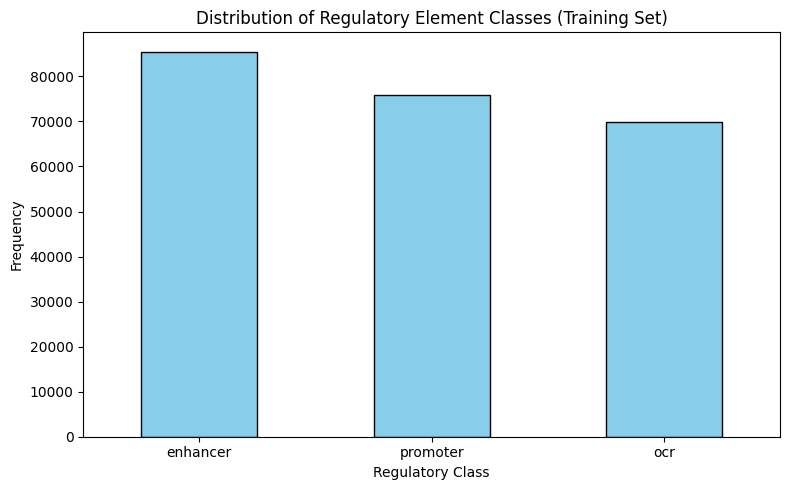

In [7]:
# Show distribution of regulatory classes in the training set
class_counts = df_train_full["RegulatoryClass"].value_counts()

plt.figure(figsize=CLASS_DIST_FIGSIZE)
class_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution of Regulatory Element Classes (Training Set)")
plt.xlabel("Regulatory Class")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Train / Validation Split
Create startified validation slice out of the training split to monitor the LSTM's loss for early stopping.

In [8]:
x_train, x_val, y_train, y_val = train_test_split(
    df_train_full["NucleotideSequence"],
    df_train_full["RegulatoryClass"],
    test_size=VAL_SIZE,
    random_state=RAND_STATE,
    stratify=df_train_full["RegulatoryClass"],
)
x_test = df_test["NucleotideSequence"]
y_test = df_test["RegulatoryClass"]

print(f"Train: {len(x_train)} | Validation: {len(x_val)} | Test: {len(x_test)}")

Train: 202422 | Validation: 28918 | Test: 57713


### K-mer Tokenization & Ordered Sequence Encoding
- Slice the sequences into a fixed size (6 based on standard)
- Used for both classic models and LSTM for fair comparison.
- Note: ordering does not matter for classic models

In [9]:
def build_kmers(sequence, k):
    """Slice a DNA string into overlapping k-length substrings ('words'), in order."""
    return " ".join(sequence[i:i + k] for i in range(len(sequence) - k + 1))

train_kmers = x_train.apply(lambda seq: build_kmers(seq, K_MER_SIZE))
val_kmers = x_val.apply(lambda seq: build_kmers(seq, K_MER_SIZE))
test_kmers = x_test.apply(lambda seq: build_kmers(seq, K_MER_SIZE))

In [ ]:
# Integer-encode the k-mers in order
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(train_kmers)

train_int_sequences = tokenizer.texts_to_sequences(train_kmers)
val_int_sequences = tokenizer.texts_to_sequences(val_kmers)
test_int_sequences = tokenizer.texts_to_sequences(test_kmers)

# Add padding; used for all models for fair comparison.
MAX_LEN = max(len(seq) for seq in train_int_sequences)

X_train_padded = pad_sequences(train_int_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_padded = pad_sequences(val_int_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_padded = pad_sequences(test_int_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {vocab_size}")
print(f"Padded sequence length (MAX_LEN): {MAX_LEN}")

Vocabulary size: 4115
Padded sequence length (MAX_LEN): 797


In [ ]:
# Encode the labels once
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

print(f"Classes: {list(label_encoder.classes_)}")

Classes: ['enhancer', 'ocr', 'promoter']


In [ ]:
# Helper methods for metrics and confusion matrix
model_metrics = {}

def evaluate_predictions(model_name, y_true, y_pred):
    """Compute, print, and store the standard metric set for one model's test predictions."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    model_metrics[model_name] = metrics
    for metric_name, value in metrics.items():
        print(f"{model_name} {metric_name}: {value:.4f}")
    return metrics


def generate_conf_matrix(y_true, y_pred, model_name):
    """Plot a labeled confusion matrix for one model's test predictions."""
    conf_mat = confusion_matrix(y_true, y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=label_encoder.classes_)
    display.plot(cmap="Blues")
    plt.title(f"{model_name} — Regulatory Class Confusion Matrix")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Direct Text Classification

In [13]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=LR_MAX_ITER, random_state=RAND_STATE)
lr_model.fit(X_train_padded, y_train_encoded)
lr_pred = lr_model.predict(X_test_padded)
evaluate_predictions("Logistic Regression", y_test_encoded, lr_pred)

/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8082
Logistic Regression Precision: 0.8131
Logistic Regression Recall: 0.8066
Logistic Regression F1-Score: 0.8085


{'Accuracy': 0.8081541420477188,
 'Precision': 0.8131428223552332,
 'Recall': 0.8066456921621962,
 'F1-Score': 0.8084655987824035}

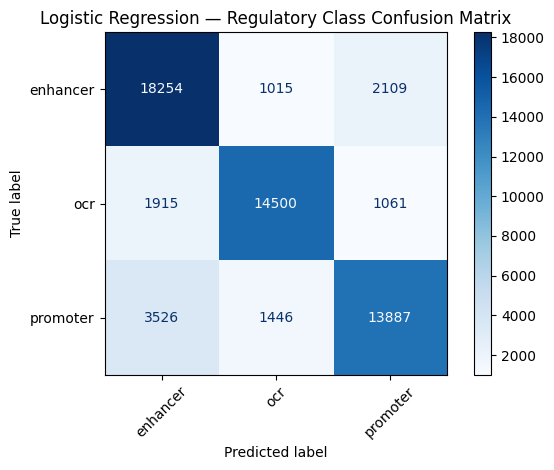

In [14]:
generate_conf_matrix(y_test_encoded, lr_pred, "Logistic Regression")

In [15]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=RAND_STATE, n_jobs=-1)
rf_model.fit(X_train_padded, y_train_encoded)
rf_pred = rf_model.predict(X_test_padded)
evaluate_predictions("Random Forest", y_test_encoded, rf_pred)

Random Forest Accuracy: 0.9219
Random Forest Precision: 0.9278
Random Forest Recall: 0.9221
Random Forest F1-Score: 0.9242


{'Accuracy': 0.921872021901478,
 'Precision': 0.9278193708080105,
 'Recall': 0.9220718076001576,
 'F1-Score': 0.9241643521095955}

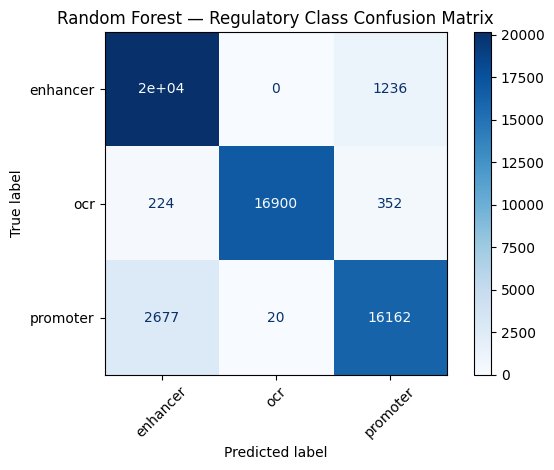

In [16]:
generate_conf_matrix(y_test_encoded, rf_pred, "Random Forest")

In [17]:
# Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_padded, y_train_encoded)
nb_pred = nb_model.predict(X_test_padded)
evaluate_predictions("Gaussian NB", y_test_encoded, nb_pred)

Gaussian NB Accuracy: 0.5755
Gaussian NB Precision: 0.7402
Gaussian NB Recall: 0.6058
Gaussian NB F1-Score: 0.5257


{'Accuracy': 0.575485592500823,
 'Precision': 0.7402384543512239,
 'Recall': 0.6057827651147001,
 'F1-Score': 0.5257018879016707}

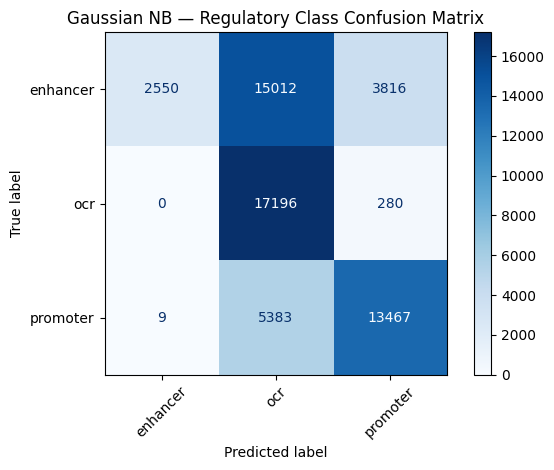

In [18]:
generate_conf_matrix(y_test_encoded, nb_pred, "Gaussian NB")

# LSTM for Direct Classification

In [ ]:
# Adjusts sequence lengths for LSTM due to memory constraints.
kmer_seq_lengths = np.array([len(seq) for seq in train_int_sequences])
print("Training k-mer sequence length distribution:")
print(f"  min={kmer_seq_lengths.min()}, mean={kmer_seq_lengths.mean():.1f}, max={kmer_seq_lengths.max()}")
for p in (50, 75, 90, 95, 99):
    print(f"  p{p:<3d} = {np.percentile(kmer_seq_lengths, p):.0f}")

LSTM_MAX_LEN = int(np.percentile(kmer_seq_lengths, LSTM_MAX_LEN_PERCENTILE))
pct_truncated = (kmer_seq_lengths > LSTM_MAX_LEN).mean() * 100
print(f"\nLSTM_MAX_LEN = {LSTM_MAX_LEN} (the p{LSTM_MAX_LEN_PERCENTILE} length) vs. MAX_LEN = {MAX_LEN} used above.")

X_train_padded_lstm = pad_sequences(train_int_sequences, maxlen=LSTM_MAX_LEN, padding="post", truncating="post")
X_val_padded_lstm = pad_sequences(val_int_sequences, maxlen=LSTM_MAX_LEN, padding="post", truncating="post")
X_test_padded_lstm = pad_sequences(test_int_sequences, maxlen=LSTM_MAX_LEN, padding="post", truncating="post")

Training k-mer sequence length distribution:
  min=66, mean=425.0, max=797
  p50  = 396
  p75  = 595
  p90  = 651
  p95  = 680
  p99  = 795

LSTM_MAX_LEN = 651 (the p90 length) vs. MAX_LEN = 797 used above.
-> ~1.2x fewer timesteps per batch; truncates the longest 9.6% of training sequences.
If this is still slow, lower LSTM_MAX_LEN_PERCENTILE in the constants cell (e.g. to 75) and re-run from here.


In [25]:
# Check for GPU availability and set the device for LSTM training
gpus = tf.config.list_physical_devices("GPU")
lstm_device = "/GPU:0" if gpus else "/CPU:0"
print(f"LSTM will train on: {lstm_device}")

tf.random.set_seed(RAND_STATE)

LSTM will train on: /GPU:0


In [ ]:
# Set up LSTM model with Conv1D front-end + Bidirectional LSTM after optimization
with tf.device(lstm_device):
    lstm_model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, mask_zero=True),
        Conv1D(filters=CONV_FILTERS, kernel_size=CONV_KERNEL_SIZE, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        Bidirectional(LSTM(LSTM_UNITS)),
        Dropout(LSTM_DROPOUT_RATE),
        Dense(num_classes, activation="softmax"),
    ])
    lstm_model.build(input_shape=(None, LSTM_MAX_LEN))
    lstm_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LSTM_LEARNING_RATE, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

lstm_model.summary()

2026-08-16 22:10:06.148607: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-08-16 22:10:06.151614: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-08-16 22:10:06.151625: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1786932606.152281 6435453 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1786932606.153787 6435453 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the m

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 651, 64)        │       263,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 651, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 325, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 482,307 (1.84 MB)

 Trainable params: 482,307 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train with early stopping + LR reduction on plateau
early_stop = EarlyStopping(monitor="val_loss", patience=LSTM_EARLY_STOP_PATIENCE, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=LSTM_LR_REDUCE_FACTOR,
    patience=LSTM_LR_REDUCE_PATIENCE,
    min_lr=LSTM_LR_MIN,
)

with tf.device(lstm_device):
    lstm_history = lstm_model.fit(
        X_train_padded_lstm, y_train_encoded,
        validation_data=(X_val_padded_lstm, y_val_encoded),
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
    )

Epoch 1/20


2026-08-16 22:10:09.843775: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


791/791 ━━━━━━━━━━━━━━━━━━━━ 725s 906ms/step - accuracy: 0.6858 - loss: 0.6483 - val_accuracy: 0.8364 - val_loss: 0.4683 - learning_rate: 5.0000e-04
Epoch 2/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 707s 893ms/step - accuracy: 0.7649 - loss: 0.5434 - val_accuracy: 0.8588 - val_loss: 0.4313 - learning_rate: 5.0000e-04
Epoch 3/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 702s 888ms/step - accuracy: 0.8068 - loss: 0.4752 - val_accuracy: 0.8320 - val_loss: 0.4388 - learning_rate: 5.0000e-04
Epoch 4/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 645s 815ms/step - accuracy: 0.8540 - loss: 0.3704 - val_accuracy: 0.7629 - val_loss: 0.5179 - learning_rate: 2.5000e-04
Epoch 5/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 686s 867ms/step - accuracy: 0.8680 - loss: 0.3323 - val_accuracy: 0.8739 - val_loss: 0.3266 - learning_rate: 1.2500e-04
Epoch 6/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 691s 873ms/step - accuracy: 0.8700 - loss: 0.3268 - val_accuracy: 0.8750 - val_loss: 0.3280 - learning_rate: 1.2500e-04
Epoch 7/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 645s 815ms/

In [26]:
# Verify LSTM Predictions
with tf.device(lstm_device):
    lstm_pred_probs = lstm_model.predict(X_test_padded_lstm)
lstm_pred = np.argmax(lstm_pred_probs, axis=1)

evaluate_predictions("LSTM", y_test_encoded, lstm_pred)

/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1804/1804 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step
LSTM Accuracy: 0.8886
LSTM Precision: 0.8959
LSTM Recall: 0.8881
LSTM F1-Score: 0.8905


{'Accuracy': 0.8885692998111344,
 'Precision': 0.8959013510507767,
 'Recall': 0.8881421492611065,
 'F1-Score': 0.8904770933430258}

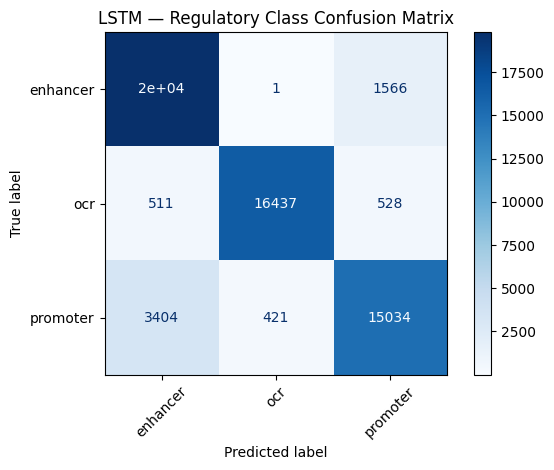

In [27]:
generate_conf_matrix(y_test_encoded, lstm_pred, "LSTM")

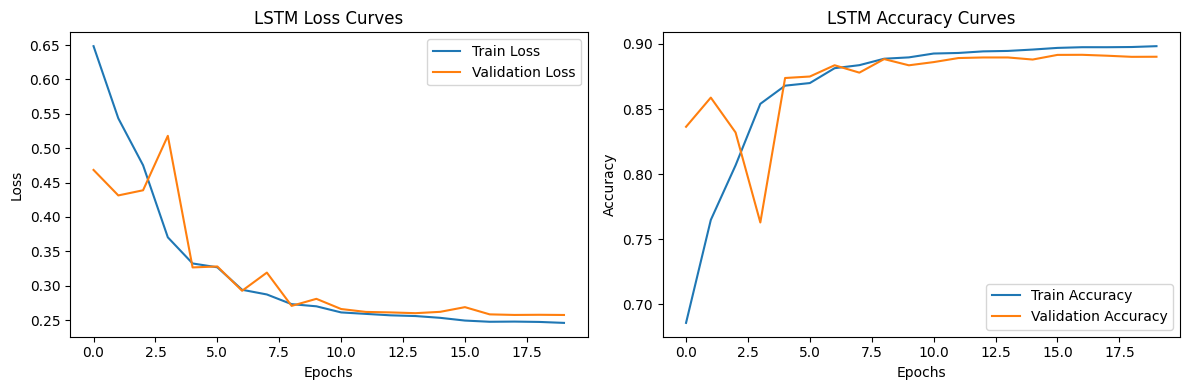

In [ ]:
# Plot LSTM loss and accuracy curves

# Loss curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history["loss"], label="Train Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Validation curves
plt.subplot(1, 2, 2)
plt.plot(lstm_history.history["accuracy"], label="Train Accuracy")
plt.plot(lstm_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

# Comparing All Four Models
With every model's metrics collected in `model_metrics`, we can build a single results table and chart instead of the midterm's separate hybrid-vs-pure comparison.

In [28]:
results_df = pd.DataFrame(model_metrics).T
results_df

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.808154,0.813143,0.806646,0.808466
Random Forest,0.921872,0.927819,0.922072,0.924164
Gaussian NB,0.575486,0.740238,0.605783,0.525702
LSTM,0.888569,0.895901,0.888142,0.890477


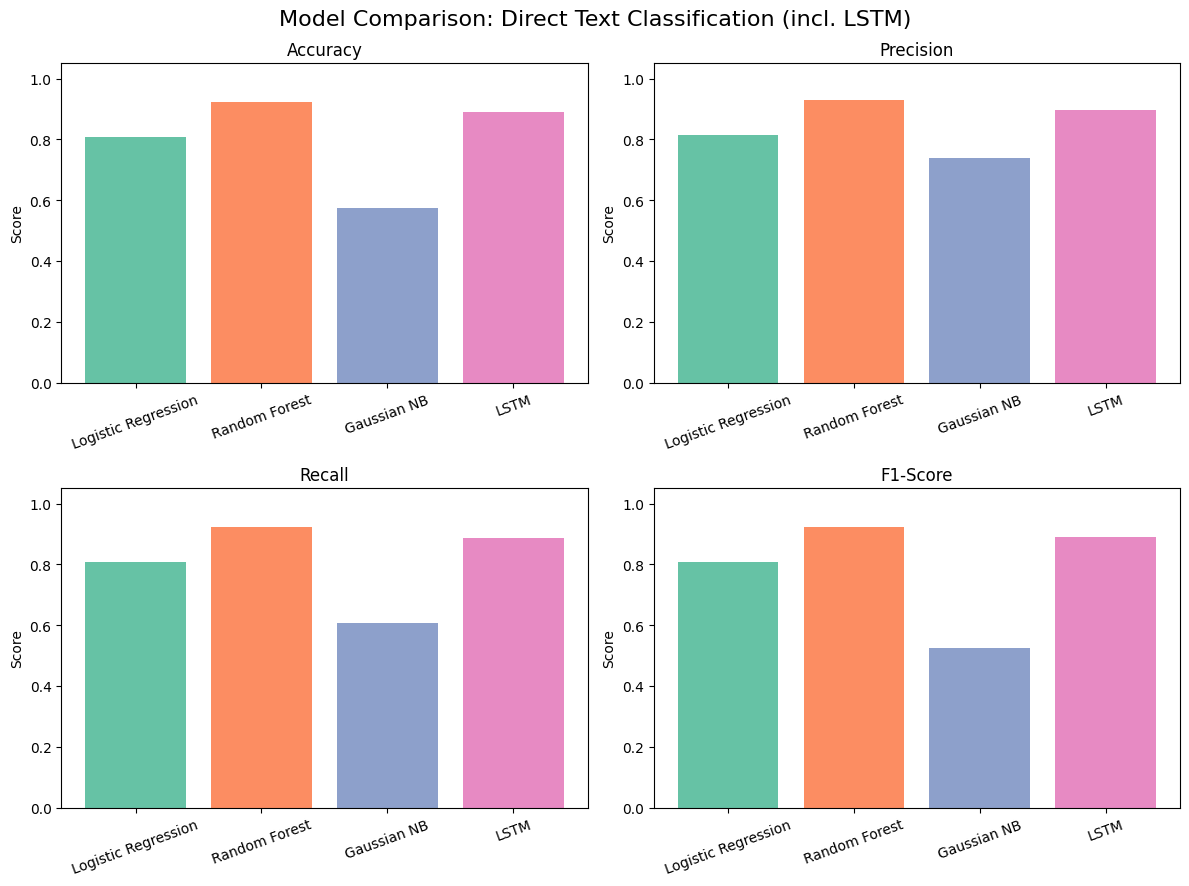

In [29]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
model_names = list(model_metrics.keys())
bar_colors = plt.cm.Set2.colors[:len(model_names)]

fig, axes = plt.subplots(2, 2, figsize=COMPARISON_FIGSIZE)
fig.suptitle("Model Comparison: Direct Text Classification (incl. LSTM)", fontsize=16)

for ax, metric_name in zip(axes.flat, metrics_to_plot):
    values = [model_metrics[name][metric_name] for name in model_names]
    ax.bar(model_names, values, color=bar_colors)
    ax.set_title(metric_name)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Final Analysis

### LSTM Optimizations (from baseline)
1. Learning rate lowered from Adam's default (0.001) to an explicit 5e-4, to stop the model from overshooting once it started learning
2. ReduceLROnPlateau scheduler added: halves the learning rate whenever val_loss plateaus, instead of training at a single fixed rate for the whole run
3. Switched from a unidirectional to a Bidirectional(LSTM(...)) to match DNA motifs better.
4. Added a Conv1D + MaxPooling1D front-end before the recurrent layer to pick up local k-mer motifs first. This was added to follow the standard pattern in genomic deep learning (e.g. DanQ).
5. EMBED_DIM raised from 32 → 64
6. LSTM_UNITS raised from 64 → 128
7. LSTM_EPOCHS increased from 10 → 20, giving the (now-stabilized) model more room to actually converge
8. LSTM_EARLY_STOP_PATIENCE increased from 3 → 5, so early stopping doesn't cut training short during a temporary plateau
9. Gradient clipping retained (clipnorm=1.0) on top of the new learning rate — cheap insurance against exploding gradients through the recurrent layer

### Results Summary

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| **Random Forest** | **0.9219** | **0.9278** | **0.9221** | **0.9242** |
| LSTM (Conv1D + BiLSTM) | 0.8886 | 0.8959 | 0.8881 | 0.8905 |
| Logistic Regression | 0.8082 | 0.8131 | 0.8066 | 0.8085 |
| Gaussian NB | 0.5755 | 0.7402 | 0.6058 | 0.5257 |

- Best model overall: **Random Forest**
- Worst model overall: **Gaussian NB**

### Classic Model Comparison

The three classic models all receive the same padded, ordered k-mer integer IDs, with no embedding layer to learn from. A token ID of 1500 isn't "twice" a token ID of 750 in any meaningful sense, yet Logistic Regression's linear decision boundary and Gaussian NB's per-feature Gaussian assumption both implicitly treat it that way. Random Forest is the only one of the three that doesn't make that assumption; it splits on thresholds, which is far more forgiving of an arbitrary integer encoding. The results confirm this exactly: **Random Forest ≫ Logistic Regression ≫ Gaussian NB**, matching the theoretical robustness ranking point for point.

### Architectural Comparison: LSTM vs. the classic models

The LSTM comfortably beats both Logistic Regression and Gaussian NB, confirming that a model capable of learning its own representation of the k-mer sequence has real value over one working directly on the raw integer encoding. It does **not**, however, beat Random Forest, and the confusion matrices show the gap is spread across all boundaries, pointing to a true representational gap:

| Error type | Random Forest | LSTM |
|---|---|---|
| enhancer → promoter | 1,236 | 1,566 |
| promoter → enhancer | 2,677 | 3,404 |
| ocr → enhancer | 224 | 511 |
| ocr → promoter | 352 | 528 |
| promoter → ocr | 20 | 421 |
| **Total misclassified** | **4,509** | **6,431** |

### Why did RF outperform LSTM?
1. **Positional motifs in gene sequences**: Depending on the type of gene sequences, there may be straightforward (linear) motifs that strongly correlate with its type/function. The RF approach can easily set a threshold decision based on that motif, whereas LSTM requires a more complex representation that may lead to less accurate representation.
2. **Architectural constraints**: LSTM is based on recurrent layers and works better for more-localized relationships. DNA sequences may have extended patterns, so using attention mechanism (transformer) in conjunction with the local processor may boost the performance.
3. **Further Tuning**: It's also possible that with additional search space and hyperparmeter tuning, the LSTM model metrics will continue to improve.
4. **Pretraining**: The LSTM architecture was built from scratch; using pretrained genomic embeddings would have been a solid choice to boost performance.

### Future Steps
1. Wider hyperparameter search space
2. Using pretrained genomic embeddings
2. Incorporating attention mechanism (transformer)
3. Adding reverse-complement augmentation (given biology of DNA)